ARTI308 - Machine Learning

# Linear Regression

Your neighbor is a real estate agent and wants some help predicting housing prices for regions in the USA. It would be great if you could somehow create a model for her that allows her to put in a few features of a house and returns back an estimate of what the house would sell for.

She has asked you if you could help her out with your new data science skills. You say yes, and decide that Linear Regression might be a good path to solve this problem!

Your neighbor then gives you some information about a bunch of houses in regions of the United States,it is all in the data set: USA_Housing.csv.

The data contains the following columns:

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at
* 'Address': Address for the house

**Let's get started!**
## Check out the data
We've been able to get some data from your neighbor for housing prices as a csv set, let's get our environment ready with the libraries we'll need and then import the data!
### Import Libraries

In [3]:
# Import necessary libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Check out the Data

In [4]:
# 1. Load the dataset into a DataFrame
df = pd.read_csv('ev_vs_petrol_dataset_v3.csv')

In [6]:
# 2. Explore the data
# Check the first 5 rows of the dataset
df.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [7]:
# Check the info of the dataset (columns, data types, and non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        1200 non-null   object 
 1   region                         1200 non-null   object 
 2   year                           1200 non-null   int64  
 3   vehicle_segment                1200 non-null   object 
 4   powertrain_type                1200 non-null   object 
 5   ev_sales                       1200 non-null   int64  
 6   petrol_car_sales               1200 non-null   int64  
 7   diesel_car_sales               1200 non-null   int64  
 8   total_vehicle_sales            1200 non-null   int64  
 9   ev_market_share                1200 non-null   float64
 10  charging_stations              1200 non-null   int64  
 11  fast_chargers_share            1200 non-null   float64
 12  avg_ev_range_km                1200 non-null   i

In [8]:
# Check the statistical summary of the numerical columns
df.describe()

,year,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
count,1200.000000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2017.500000,6.360236e+04,7.733063e+05,1.409369e+05,9.778455e+05,6.327992,5.693898e+04,14.437750,265.872500,1.342239,0.169508,35651.525000,74.609000,190.837000,2910.940000,58.761860,64.002958,0.018333
std,4.611694,4.079506e+05,1.756934e+06,2.913472e+05,2.211799e+06,13.231723,3.359383e+05,10.057529,121.994051,0.363461,0.079298,23899.013679,14.858811,363.100639,2477.306742,20.092871,71.386797,0.134210
min,2010.000000,5.000000e+00,1.727000e+03,1.500000e+02,1.748000e+04,0.000000,0.000000e+00,0.000000,106.000000,0.482900,0.066990,1359.000000,30.900000,5.400000,0.000000,19.484000,-40.960000,0.000000
25%,2013.750000,2.002500e+02,8.870500e+04,1.951075e+04,1.300465e+05,0.077500,4.917500e+02,6.000000,150.000000,1.097000,0.098750,11077.250000,64.175000,30.175000,0.000000,43.600000,16.372500,0.000000
50%,2017.500000,2.731500e+03,2.294785e+05,5.136100e+04,2.905130e+05,0.830000,4.090000e+03,12.900000,238.500000,1.352000,0.158000,37329.000000,79.900000,94.250000,2794.500000,59.350000,44.165000,0.000000
75%,2021.250000,1.990500e+04,6.385320e+05,1.111910e+05,7.624482e+05,5.832500,2.251800e+04,20.950000,380.250000,1.568500,0.220250,50930.000000,84.075000,159.575000,4973.750000,74.825000,80.907500,0.000000
max,2025.000000,7.670056e+06,1.477369e+07,2.014595e+06,1.884998e+07,95.000000,4.338106e+06,49.300000,507.000000,2.153000,0.379040,103437.000000,98.500000,1900.800000,8952.000000,95.602000,300.000000,1.000000


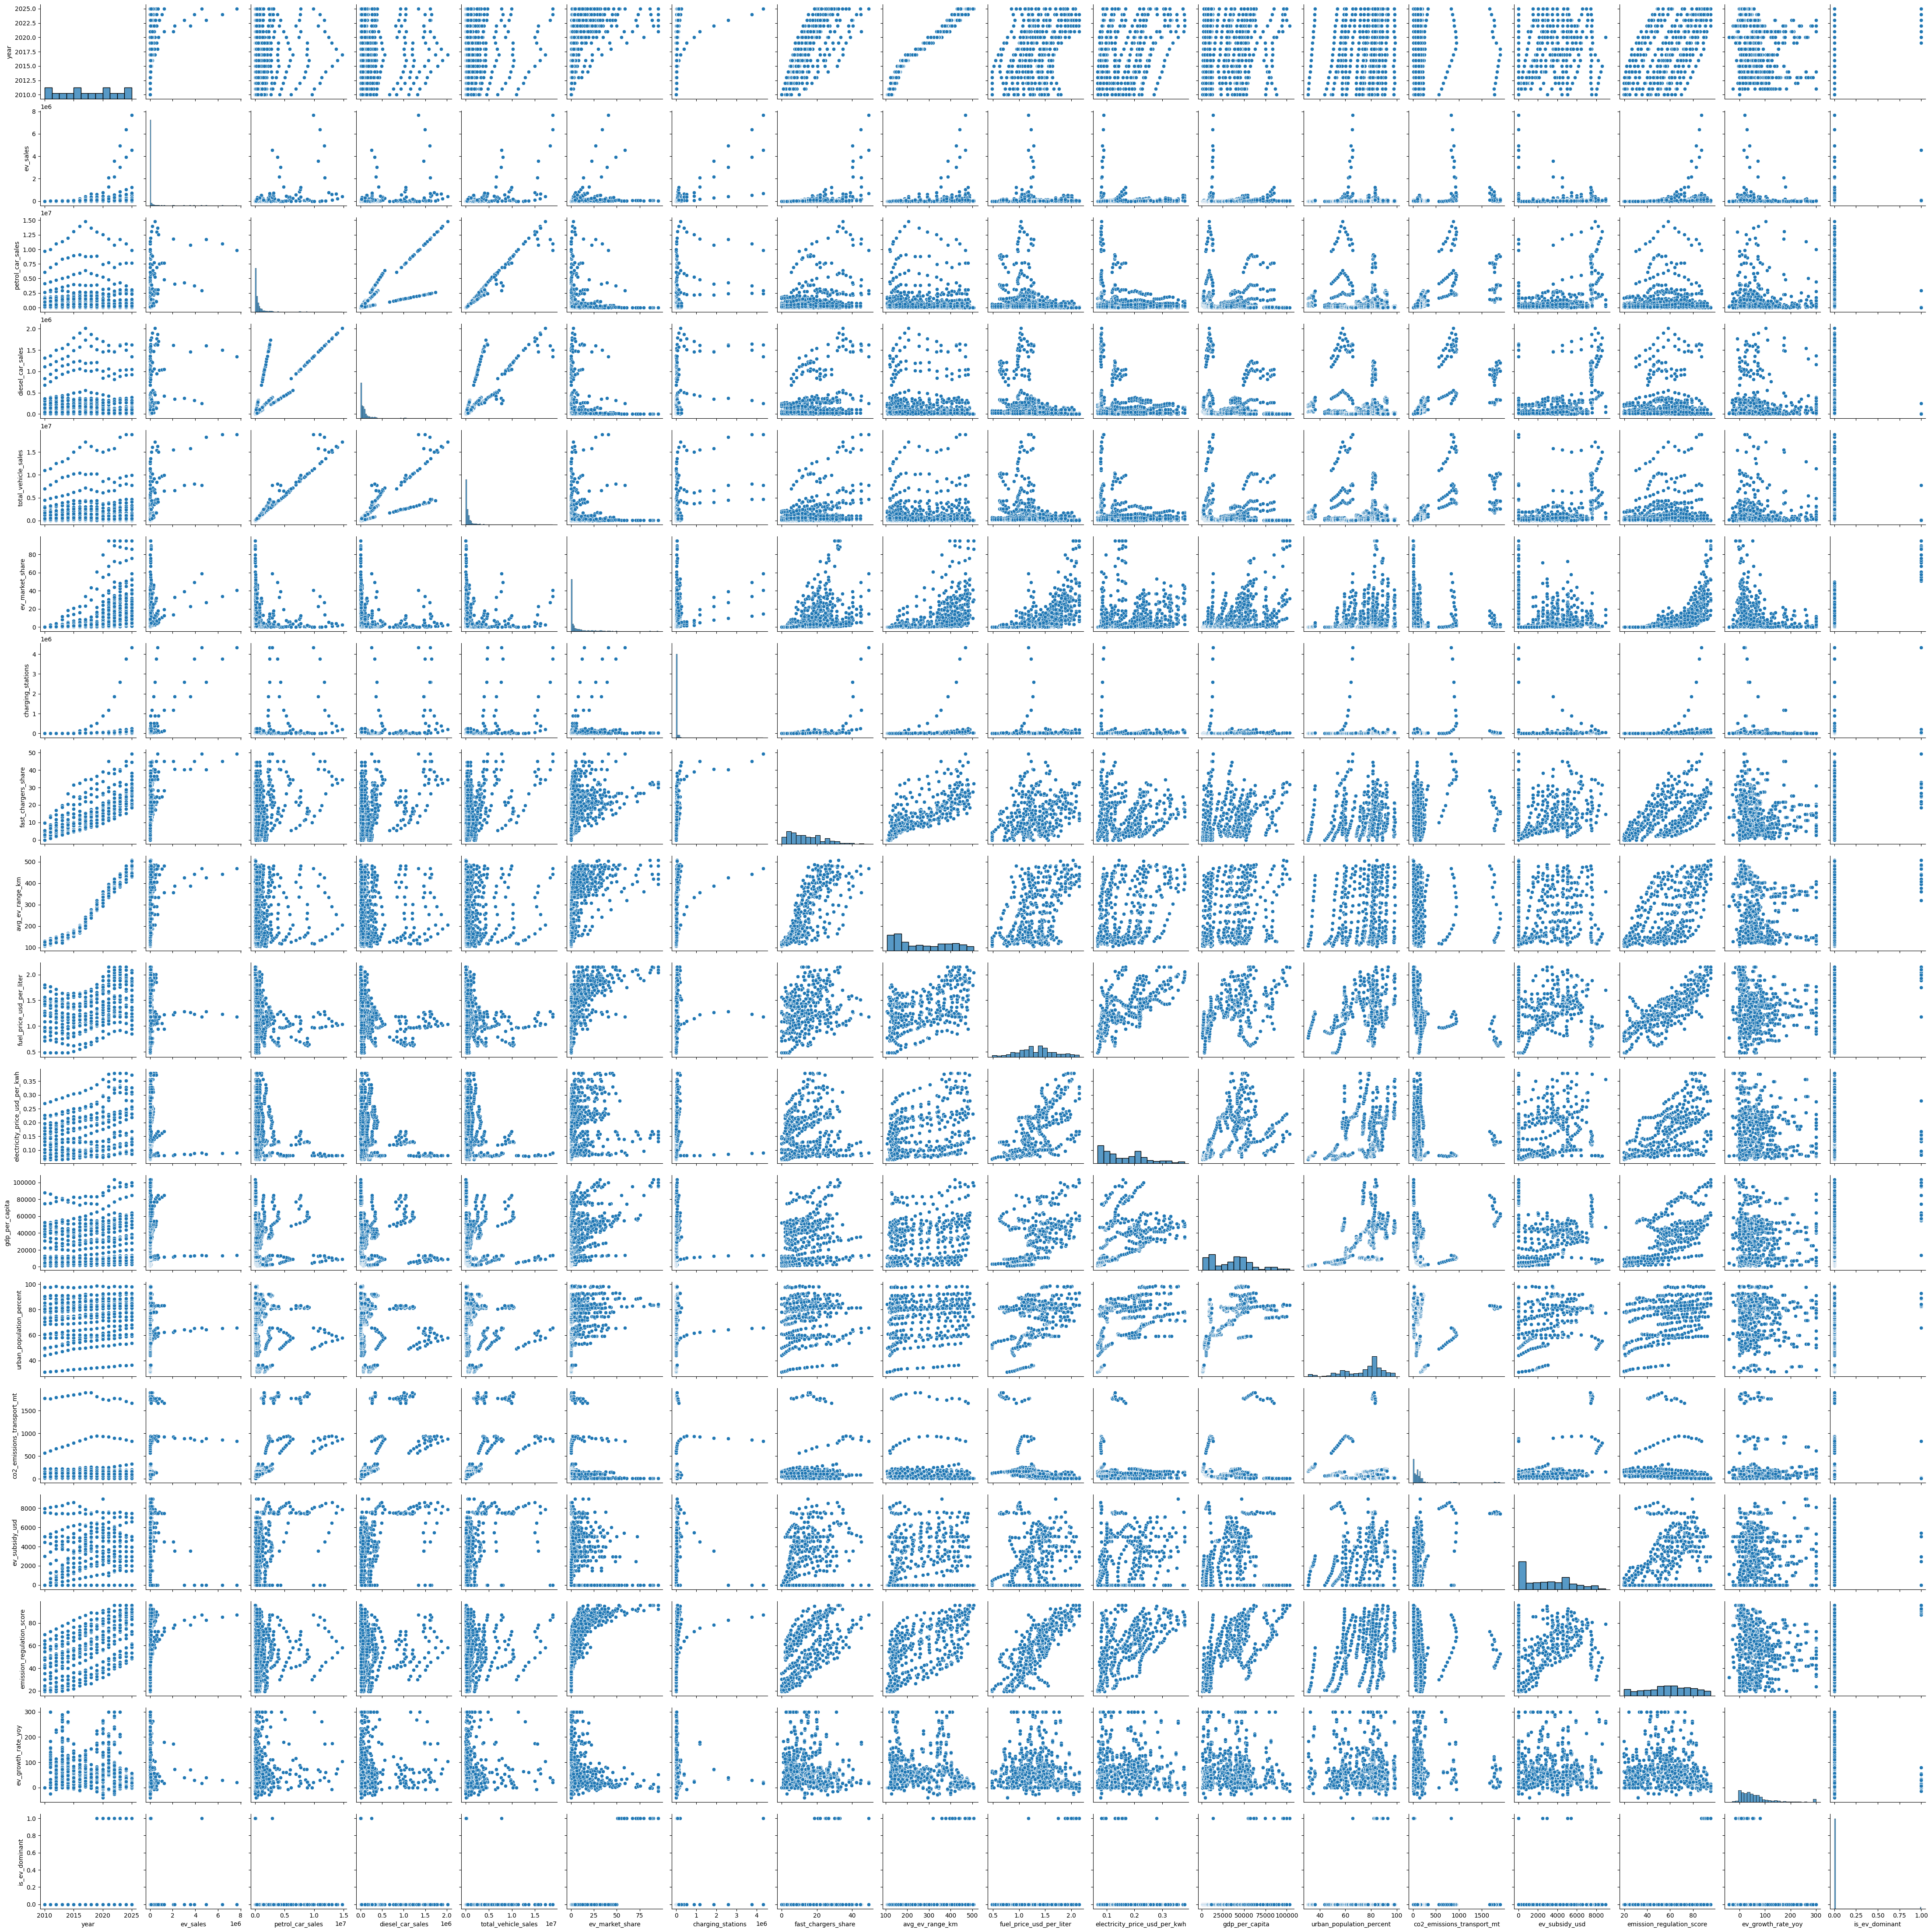

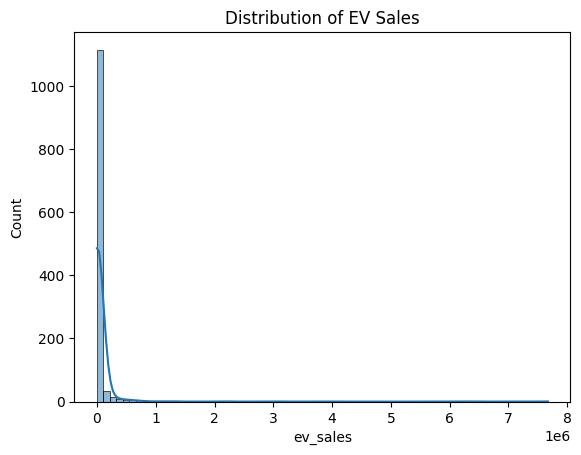

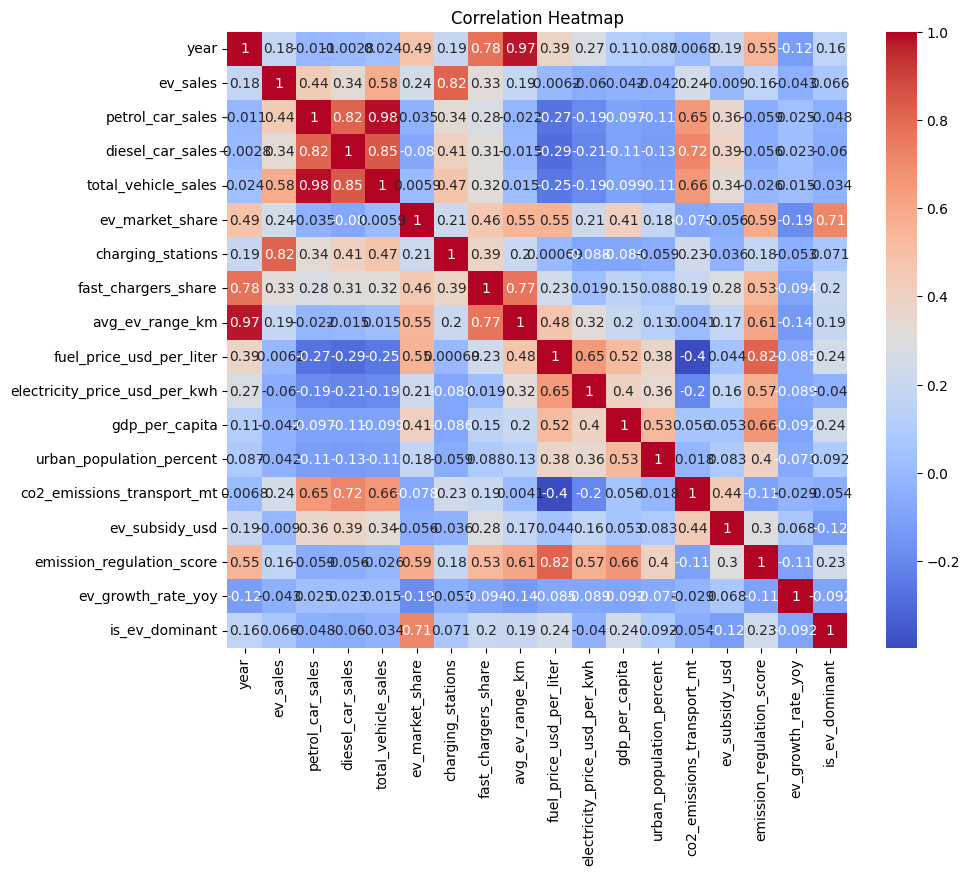

In [14]:
# Create a pairplot to visualize relationships between all numerical columns
sns.pairplot(numeric_df)
plt.show()

# Create a histogram to see the distribution of the target variable (ev_sales)
sns.histplot(numeric_df['ev_sales'], kde=True)
plt.title('Distribution of EV Sales')
plt.show()

# Create a heatmap to show the correlation between different features
# annot=True shows the exact correlation numbers on the plot
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# 3. Perform basic data cleaning
# Drop any rows that contain missing values (NaN)
df.dropna(inplace=True)

# Feature Engineering




In [10]:
# 4. Apply feature engineering
# Select only numerical columns to be used in our mathematical model
numeric_df = df.select_dtypes(include=['float64', 'int64'])

## Prepare the data for modeling


In [11]:
# 5. Prepare the data for modeling
# Define features (X) and the target variable (y)
# We drop 'ev_sales' from X because it is the target we want to predict
X = numeric_df.drop('ev_sales', axis=1)
y = numeric_df['ev_sales']

# Split the data into training and testing sets (70% for training, 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Training the Model

In [12]:
# 6. Train a model
# Create an instance of a LinearRegression model
lm = LinearRegression()

# Train (fit) the model on the training data
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Model Evaluation

Let's evaluate the model by checking out it's coefficients and how we can interpret them.

In [13]:
# 7. Evaluate the model performance
# Get predictions off the test set
predictions = lm.predict(X_test)

# Print out the evaluation metrics to see how well the model performed
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 1.2408269547650422e-09
MSE: 6.576319867250065e-18
RMSE: 2.5644336347915234e-09



### Task:
In this task, you will apply what you have learned in this lab on a new dataset.

We will work with the Ecommerce Customers dataset (you will find it on Blackboard)

1. Load the dataset into a DataFrame
2. Explore the data (head, info, describe)
3. Perform basic data cleaning if needed
4. Apply feature engineering (if applicable)
5. Prepare the data for modeling
6. Train a model (use the same model used in the lab)
7. Evaluate the model performance